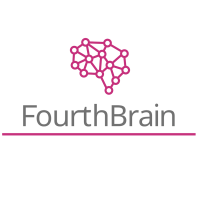
# FOURTHBRAIN MLE 10
> INSTADEEP INDUSTRY CAPSTONE PROJECT

# > THE LANGUAGE OF PROTEINS

> TEAM
* ANJANA SENGUPTA
* JONATHAN A. GRANT
* SAM DEO
* SHAISTA HUSSAIN  

*> NB:  PFAM DATASET*

# **1. BUSINESS PROBLEM**

# 1.1 Description

Proteins are structurally complex and functionally sophisticated molecules that have developed over billions of years.  Proteins, and their amino acid precursors, are the essential building blocks of life, where all proteins are composed of chains of amino acid sequences, maintained by peptide bonds.

The structure and function of each protein is determined by the specific amino acids used to make it and how they are arranged. Understanding this relationship between amino acid sequence and protein function is a long-standing problem in moleculer biology with far-reaching scientific implications in personalized medicine, genomics and in developing targetted pharmaceuticals.

# 1.2 Problem Statement
- Amino acids are like the letters of the proteins that are words; these words have functions and when they interact with other words, they can change their functions.
- Given an amino acid sequence, is it possible to predict which class of proteins the sequence belongs to?
- **How?**
- Classification of protein's amino acid sequence to one of the protein family accession, based on PFam dataset.

# **2. DATA**

# 2.1 Source
- [Pfam seed random split](https://www.kaggle.com/googleai/pfam-seed-random-split)
- Pfam 34.0 is a protein family database with annotations and sequence alignments.
- Protein families are represented by multiple sequence alignments and hidden Markov models (HMMs)
- A profile hidden Markov model (HMM) is automatically built from the seed alignment and searched against a sequence database called pfamseq using the HMMER software (http://hmmer.org/). 
- All sequence regions that satisfy a family-specific curated threshold (gathering threshold), are aligned to the profile HMM to create the full alignment.
- Pfam is based on the UniProtKB sequence database and the NCBI GenPept, and on sequences from metagenomics projects. 

# 2.2 Distribution
We random split(train, val, test) the dataset:
  - **Train - 80%** (For training the models).
  - **Val - 10%** (For hyperparameter tuning/model validation).
  - **Test - 10%** (For acessing the model performance).

# 2.3 Format
**Each CSV contains this data format:**

- `sequence`: These are usually the input features to the model. Amino acid sequence for this domain. There are 20 very common amino acids (frequency > 1,000,000), and 4 amino acids that are quite uncommon: X, U, B, O, Z.
eg. sequence: HWLQMRDSMNTYNNMVNRCFATCIRSFQEKKVNAEEMDCTKRCVTKFVGYSQRVALRFAE

- `family_accession`: These are usually the labels for the model. Accession number in form PFxxxxx.y (Pfam), where xxxxx is the family accession, and y is the version number. Some values of y are greater than ten, and so 'y' has two digits.
eg. family_accession: PF02953.15

- `sequence_name`: Sequence name, in the form "uniprot_accession_id/start_index-end_index". 
eg. sequence_name: C5K6N5_PERM5/28–87

- `aligned_sequence`: Contains a single sequence from the multiple sequence alignment (with the rest of the members of the family in seed, with gaps retained.
eg. aligned_sequence: ….HWLQMRDSMNTYNNMVNRCFATCI………..RS.F….QEKKVNAEE…..MDCT….KRCVTKFVGYSQRVALRFAE

- `family_id`: One word name for family. 
eg.family_id: zf-Tim10_DDP
  

# **3. OBJECTIVES**

# 3.1 Goal
- To predict protein family accession from its amino acids sequence with high accuracy.

# 3.2 Research Questions
1. Can we use deep learning that learns the relationship between unaligned amino acid sequences and their functional annotations across all PFAM families?
2. Can we improve class-wise accuracy versus existing published models?
3. Can we outline bias and errors in our model, and suggest solutions to these?

# **4. BASELINE**
* The proposed dataset was in 3 parts, each with test and train sets
i) Anti cancer protein class (ACP)
ii) Anti microbial protein class (AMP)
iii) Anti DNA Binding protein class (ADNABP)

* These are large categories, i.e AMP represents microbes which constitute viruses, bacteria, fungi and parasitic /protozoal species; and within each of these sub headings, the classifications continue in great detail and with specificity.
 
* The dataset was also limited in that it used a binary identification of each of the three classes, to predict if a sequence is ACP/AMP/ADNABP or not.

* Using the PFAM dataset increases the training and testing quantity, as well as increases the classification ability to 19,632 protein families.

# Iterations of our work process

1. Baseline model:
* Protein Classification on PDB dataset https://colab.research.google.com/drive/1UdB8tBaKF9YaV_Vz_v3MBvNG0CfWpfrS?usp=sharing 
* "summary of statistical findings are..."
* We found that DATA CLASSIFICATION - Random Forest Decision Tree Gradient Boosting Gaussian Naive Bayes Multinomial Naive Bayes Support Vector Machine (SVM) K Nearest Neighbors (KNN) Logistic Regression with OneVsRest Random Forest is the best among all above models. KNN also works well whereas all other models give very poor performance.
* In Character level 1d CNN and LSTM using keras and TensorFlow in which CNN performed well also.


2. ProtT5 embeddings: https://colab.research.google.com/drive/1xEplFlL29t5hWjldvP48ZAnNaj8gr64M?usp=sharing

3. Count Vectorization on PDB Dataset:  https://colab.research.google.com/drive/1KC1jFXByjyN6YF1zJ8f0xCyVuGHX6F_k?usp=sharing

4. EDA on ACP/AMP/ADNABP Dataset https://www.kaggle.com/code/luckyapollo/pfam-proteinprediction

5. EDA on ACP Dataset: https://colab.research.google.com/drive/1mlCJuH6rVh8dsOIobHNlLKArOoP-o6W1?usp=sharing

6. EDA on DNABPs Dataset: https://colab.research.google.com/drive/1uZ3VDsMRcxvfLi-ldQczT1PdqmoHWHxy?usp=sharing 

7. EDA on AMPs Dataset: https://colab.research.google.com/drive/1UdB8tBaKF9YaV_Vz_v3MBvNG0CfWpfrS?usp=sharing and

https://colab.research.google.com/drive/1fiQNvhN6wtqOCB3PMyrZIYRvRyl9kQqm?usp=sharing

8. Keras tokenizers on ACP/AMP/ADNABP Dataset: https://www.kaggle.com/luckyapollo/protein-sequence-family

9. Naive bayes and ADA boost on PFAM - COPY of code from kaggle user https://www.kaggle.com/code/luckyapollo/predicting-protein-classification

# **5.  MACHINE LEARNING SOLUTIONS**

- It is a multi class classification problem
- for a given sequence of amino acids, predict protein family

# 5.1 Performance Metrics

- Multi class log loss
- Accuracy

# **6. LOADING DATA & RESOURCES**

### 6.1 Importing Libraries

In [1]:
%matplotlib inline

import os
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from prettytable import PrettyTable
from IPython.display import Image

from sklearn.preprocessing import LabelEncoder

from keras.models import Model
from keras.regularizers import l2
from keras.constraints import max_norm
from keras.utils import to_categorical
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.callbacks import EarlyStopping
from keras.layers import Input, Dense, Dropout, Flatten, Activation
from keras.layers import Conv1D, Add, MaxPooling1D, BatchNormalization
from keras.layers import Embedding, Bidirectional, LSTM, CuDNNLSTM, GlobalMaxPooling1D

In [2]:
import tensorflow as tf
# tf.logging.set_verbosity(tf.logging.ERROR)

### 6.2 Loading Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = '/content/drive/MyDrive/MLE/protein_data/random_split'
print('Available data', os.listdir(data_path))

Available data ['dev', 'test', 'train']


The data is randomly splitted in three folders [train(80%), test(10%), dev(10%)

In [6]:
# reading and concatinating data for each folder.

def read_data(partition):
  data = []
  for fn in os.listdir(os.path.join(data_path, partition)):
    with open(os.path.join(data_path, partition, fn)) as f:
      data.append(pd.read_csv(f, index_col=None))
  return pd.concat(data)

In [7]:
# reading all data_partitions

df_train = read_data('train')
df_val = read_data('dev')
df_test = read_data('test')

In [8]:
#checking for duplicates
print(df_train.duplicated().any())
print(df_val.duplicated().any())
print(df_test.duplicated().any())

False
False
False


# **7. EXPLORATORY DATA ANALYSIS**

# 7.1 Using Pandas dataframes to construct the encoding.

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1086741 entries, 0 to 13692
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   family_id         1086741 non-null  object
 1   sequence_name     1086741 non-null  object
 2   family_accession  1086741 non-null  object
 3   aligned_sequence  1086741 non-null  object
 4   sequence          1086741 non-null  object
dtypes: object(5)
memory usage: 49.7+ MB


In [10]:
df_train.head()

,family_id,sequence_name,family_accession,aligned_sequence,sequence
0,Cation_ATPase_C,A0B648_METTP/704-874,PF00689.21,PAPLLALQILWINVVAEDFP.AIGLAVEPA.R...SGIMNE.RPR....,PAPLLALQILWINVVAEDFPAIGLAVEPARSGIMNERPRNPKEPIL...
1,DUF1635,U5GKL9_POPTR/18-237,PF07795.11,KTMDDLRNSLLYTTLELEQTKVAVQEELRKKDDQLFHLKDLLSKAI...,KTMDDLRNSLLYTTLELEQTKVAVQEELRKKDDQLFHLKDLLSKAI...
2,TGT,A5GIE9_SYNPW/12-370,PF01702.18,C..RHT.A....ARCGCFQT......PH.G.....P...VTTP.RF...,CRHTAARCGCFQTPHGPVTTPRFMPVGTLATVKGVTADQLATTGAQ...
3,HRM,Q9PWB7_DANRE/90-158,PF02793.22,VGVCVPEWDGL.ICWPQGFPGTLTKTPCPGYIYDFNHA...........,VGVCVPEWDGLICWPQGFPGTLTKTPCPGYIYDFNHAAHAYRRCDS...
4,Imm-NTF2-2,A4YMX6_BRASO/45-110,PF15631.6,TAARIAERYLAVHYPAFDTIAMPPIVDDEGD...VWKVSYELPPNM...,TAARIAERYLAVHYPAFDTIAMPPIVDDEGDVWKVSYELPPNMAGG...


- each character reperesents one of the 24(20 common + 4 uncommon) amino acids in the sequence

In [11]:
# unaligned sequence
df_train.head(1)['sequence'].values[0]

'PAPLLALQILWINVVAEDFPAIGLAVEPARSGIMNERPRNPKEPILSRDLLIYTIGTSAAMLIGTLGLFLLNIDGGLGYARTVAFASLGICAIYNAYSSRSFHHSVLQMNPMGNRKLLAGIVTSLASVLMVIYVPVFQGAFETLPLTMNSWLQVWLVSTIVIVVAEVLKRS'

In [12]:
# Given data size
print('Train size: ', len(df_train))
print('Val size: ', len(df_val))
print('Test size: ', len(df_test))

Train size:  1086741
Val size:  126171
Test size:  126171


In [13]:
def calc_unique_cls(train, test, val):
  """
  Prints # unique classes in data sets.
  """
  train_unq = np.unique(train['family_accession'].values)
  val_unq = np.unique(val['family_accession'].values)
  test_unq = np.unique(test['family_accession'].values)

  print('Number of unique classes in Train: ', len(train_unq))
  print('Number of unique classes in Val: ', len(val_unq))
  print('Number of unique classes in Test: ', len(test_unq))

In [14]:
# Unique classes in the given dataset : [df_train, df_val and df_test]

calc_unique_cls(df_train, df_test, df_val)

Number of unique classes in Train:  17929
Number of unique classes in Val:  13071
Number of unique classes in Test:  13071


The number of unique classes in each set is as follows:
* Train (17929)
* Val (12071)
* Test (13071)

# 7.2 Sequence Counts

In [15]:
# Length of sequence in train data.
df_train['seq_char_count']= df_train['sequence'].apply(lambda x: len(x))
df_val['seq_char_count']= df_val['sequence'].apply(lambda x: len(x))
df_test['seq_char_count']= df_test['sequence'].apply(lambda x: len(x))

# Observations
***There are 1086741 sequences in the train dataframe , 126171 sequences in the test and 126171 sequences validation dataframes.***

In [16]:
def plot_seq_count(df, data_name):
  sns.distplot(df['seq_char_count'].values)
  plt.title(f'Sequence char count: {data_name}')
  plt.grid(True)

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

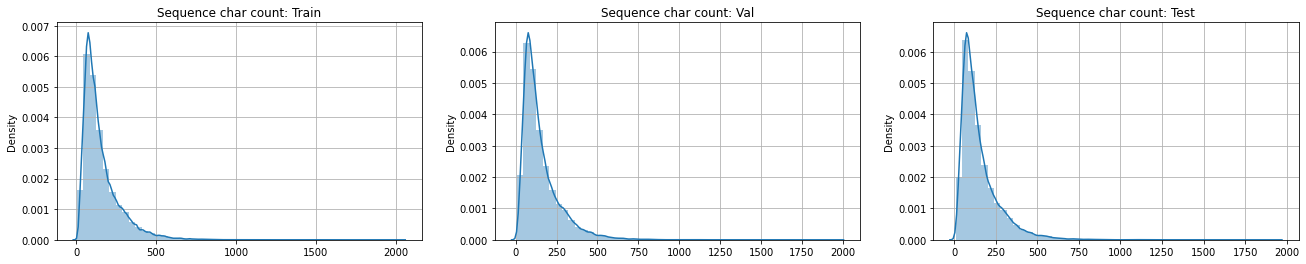

In [17]:
#visualize sequence character counts in train, val and test
plt.subplot(1, 3, 1)
plot_seq_count(df_train, 'Train')

plt.subplot(1, 3, 2)
plot_seq_count(df_val, 'Val')

plt.subplot(1, 3, 3)
plot_seq_count(df_test, 'Test')

plt.subplots_adjust(right=3.0)
plt.show()

# Observations
***- Most of the unaligned amino acid sequences have character counts in the range of 50-250.***

# 7.3 Sequence Code Frequency
Amino acid sequences are represented with their corresponding 1 letter code, for example, code for alanine is (A), arginine is (R) etc. <a href='http://www.cryst.bbk.ac.uk/education/AminoAcid/the_twenty.html'>amino acid codes</a>.

In [18]:
#codes
def get_code_freq(df, data_name):
  
  df = df.apply(lambda x: " ".join(x))
  
  codes = []
  for i in df: # concatination of all codes
    codes.extend(i)

  codes_dict= Counter(codes)
  codes_dict.pop(' ') # removing white space
  
  print(f'Codes: {data_name}')
  print(f'Total unique codes: {len(codes_dict.keys())}')

  df = pd.DataFrame({'Code': list(codes_dict.keys()), 'Freq': list(codes_dict.values())})
  return df.sort_values('Freq', ascending=False).reset_index()[['Code', 'Freq']]

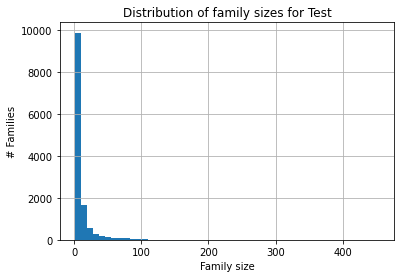

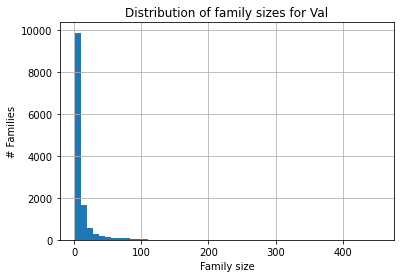

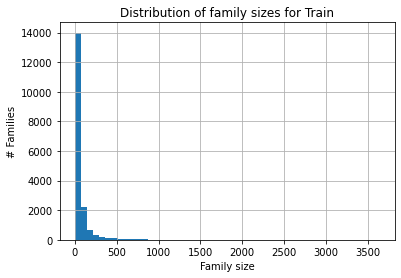

In [19]:
#visualize distribution of family sizes
partitions = {'Test': df_test, 'Val': df_val, 'Train': df_train}
for name, partition in partitions.items():
    partition.groupby('family_accession').size().hist(bins=50)
    plt.title('Distribution of family sizes for %s' % name)
    plt.ylabel('# Families')
    plt.xlabel('Family size')
    plt.show()

In [20]:
# train code sequence
train_code_freq = get_code_freq(df_train['sequence'], 'Train')
train_code_freq

Codes: Train
Total unique codes: 25


,Code,Freq
0,L,17062816
1,A,14384873
2,V,11913147
3,G,11845579
4,E,10859966
5,S,10597822
6,I,10234455
7,R,9406165
8,D,9371097
9,K,9127832


In [21]:
# val code sequence
val_code_freq = get_code_freq(df_val['sequence'], 'Val')
val_code_freq

Codes: Val
Total unique codes: 22


,Code,Freq
0,L,1967025
1,A,1667703
2,V,1382128
3,G,1376124
4,E,1249356
5,S,1210750
6,I,1185722
7,R,1085950
8,D,1080572
9,K,1047638


In [22]:
# test code sequence
test_code_freq = get_code_freq(df_test['sequence'], 'Test')
test_code_freq

Codes: Test
Total unique codes: 24


,Code,Freq
0,L,1967046
1,A,1668137
2,V,1380962
3,G,1375349
4,E,1251000
5,S,1210559
6,I,1184239
7,R,1085786
8,D,1078379
9,K,1045957


Unique codes are as follows:
* Train (25)
* Val (22)
* Test (24)

In [23]:
def plot_code_freq(df, data_name):
  
  plt.title(f'Code frequency: {data_name}')
  sns.barplot(x='Code', y='Freq', data=df)

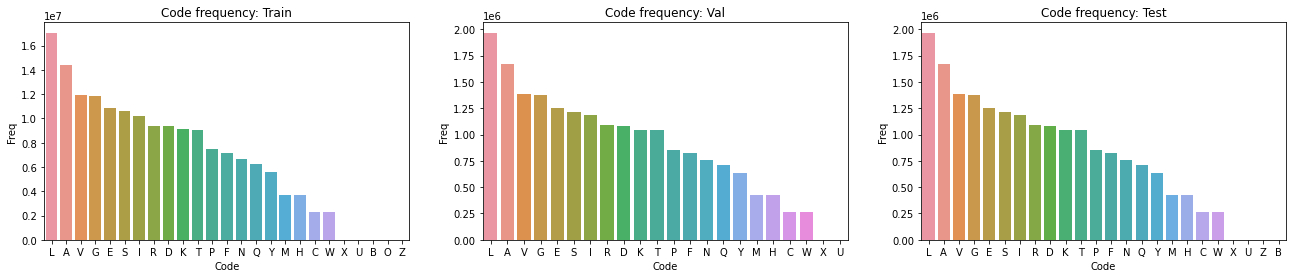

In [24]:
#visualize code frequencies in train, val and test
plt.subplot(1, 3, 1)
plot_code_freq(train_code_freq, 'Train')

plt.subplot(1, 3, 2)
plot_code_freq(val_code_freq, 'Val')

plt.subplot(1, 3, 3)
plot_code_freq(test_code_freq, 'Test')

plt.subplots_adjust(right=3.0)
plt.show()

# *Observations*
- Most frequent amino acid code is L followed by A, V, G.
- As we can see, that the uncommon amino acids (i.e., X, U, B, O, Z) are present in very less quantity. 
- Therefore we can consider only 20 common natural amino acids for sequence encoding.

# 7.4 Number of protein families with most sequences 

In [25]:
df_train.groupby('family_id').size().sort_values(ascending=False).head(20)

family_id
Methyltransf_25    3637
LRR_1              1927
Acetyltransf_7     1761
His_kinase         1537
Bac_transf         1528
Lum_binding        1504
DNA_binding_1      1345
Chromate_transp    1265
Lipase_GDSL_2      1252
DnaJ_CXXCXGXG      1210
SRP54_N            1185
WD40               1173
OTCace_N           1171
PEP-utilizers      1147
Glycos_trans_3N    1138
THF_DHG_CYH        1113
Prenyltransf       1104
HTH_1              1064
Maf                1061
DHH                1057
dtype: int64

In [26]:
df_val.groupby('family_id').size().sort_values(ascending=False).head(20)

family_id
Methyltransf_25    454
LRR_1              240
Acetyltransf_7     219
His_kinase         192
Bac_transf         190
Lum_binding        187
DNA_binding_1      168
Chromate_transp    157
Lipase_GDSL_2      156
DnaJ_CXXCXGXG      151
SRP54_N            148
OTCace_N           146
WD40               146
PEP-utilizers      143
Glycos_trans_3N    142
THF_DHG_CYH        138
Prenyltransf       138
HTH_1              133
Maf                132
DHH                131
dtype: int64

In [27]:
df_test.groupby('family_id').size().sort_values(ascending=False).head(20)

family_id
Methyltransf_25    454
LRR_1              240
Acetyltransf_7     219
His_kinase         192
Bac_transf         190
Lum_binding        187
DNA_binding_1      168
Chromate_transp    157
Lipase_GDSL_2      156
DnaJ_CXXCXGXG      151
SRP54_N            148
OTCace_N           146
WD40               146
PEP-utilizers      143
Glycos_trans_3N    142
THF_DHG_CYH        138
Prenyltransf       138
HTH_1              133
Maf                132
DHH                131
dtype: int64

# *Observations*

- ***Top 20 classes are same across all the sets [train, test, val].***
- The commonest families are :
- Methyltransf_25    454;
LRR_1              240
Acetyltransf_7     219
His_kinase         192
Bac_transf         190
Lum_binding        187
DNA_binding_1      168

- ***Test and Val sets have almost same frequency for the top 20 classes.  ***

# 7.5 Considering 1000 classes based on no. of observations.

In [28]:
# Considering top 1000 classes 

classes = df_train['family_accession'].value_counts()[:1000].index.tolist()
len(classes)

1000

In [29]:
# Filtering data based on considered 1000 classes.
train_sm = df_train.loc[df_train['family_accession'].isin(classes)].reset_index()
val_sm = df_val.loc[df_val['family_accession'].isin(classes)].reset_index()
test_sm = df_test.loc[df_test['family_accession'].isin(classes)].reset_index()

print('Data size after considering 1000 classes for each data split:')
print('Train size :', len(train_sm))
print('Val size :', len(val_sm))
print('Test size :', len(test_sm))

Data size after considering 1000 classes for each data split:
Train size : 439493
Val size : 54378
Test size : 54378


In [30]:
# No. of unique classes after reducing the data size.

calc_unique_cls(train_sm, test_sm, val_sm)

Number of unique classes in Train:  1000
Number of unique classes in Val:  1000
Number of unique classes in Test:  1000


# **8. ML MODELS**

# 8.1 Text Preprocessing

*** The 20 amino acids (that make up proteins) each have assigned to them both three-letter (can be upper or lower case) and one-letter codes (upper case)to expedite and make it easier to notate.***  
 
*** The list provides the notations  in the format of: ***

**amino acid name - 3 letter code - 1 letter code **

1. alanine - ala - A  
2. arginine - arg - R  
3. asparagine - asn - N  
4. aspartic acid - asp - D  
5. cysteine - cys - C  
6. glutamine - gln - Q  
7. glutamic acid - glu - E  
8. glycine - gly - G  
9. histidine - his - H  
10. isoleucine - ile - I  
11. leucine - leu - L  
12. lysine - lys - K  
13. methionine - met - M  
14. phenylalanine - phe - F  
15. proline - pro - P  
16. serine - ser - S  
17. threonine - thr - T  
18. tryptophan - trp - W  
19. tyrosine - tyr - Y  
20. valine - val - V


When it is not possible two differentiate two closely related amino acids, we have the special cases of:
21. asparagine/aspartic acid - asx - B
22. glutamine/glutamic acid - glx - Z

In [31]:

# 1 letter code for 20 natural amino acids

codes = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
         'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

def create_dict(codes):
  char_dict = {}
  for index, val in enumerate(codes):
    char_dict[val] = index+1

  return char_dict

char_dict = create_dict(codes)

print(char_dict)
print("Dict Length:", len(char_dict))

{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20}
Dict Length: 20


# 8.2 Data Preparation 
# *8.21 Process*
- Calculate the most and least frequently appearing characters; stored with indices.  
- Fill spaces between each character in each sequence
- Replace the characters by indices of characters as frequence-feature
- Using the top 20 characters pad the vectors   

- These methods do not consider the interdependence of amino acids based on their relative positions.  

# *8.22 One Hot Encoding (ohe)*
- Produces a 20-column vector for each position that only contains a 1 where the letter corresponds to that amino acid. 


In [32]:
def integer_encoding(data):
  """
  - Encodes code sequence to integer values.
  - 20 common amino acids are taken into consideration
    and rest 4 are categorized as 0.
  """
  
  encode_list = []
  for row in data['sequence'].values:
    row_encode = []
    for code in row:
      row_encode.append(char_dict.get(code, 0))
    encode_list.append(np.array(row_encode))
  
  return encode_list

In [33]:
train_encode = integer_encoding(train_sm) 
val_encode = integer_encoding(val_sm) 
test_encode = integer_encoding(test_sm) 

In [34]:
# padding sequences

max_length = 100
train_pad = pad_sequences(train_encode, maxlen=max_length, padding='post', truncating='post')
val_pad = pad_sequences(val_encode, maxlen=max_length, padding='post', truncating='post')
test_pad = pad_sequences(test_encode, maxlen=max_length, padding='post', truncating='post')

train_pad.shape, val_pad.shape, test_pad.shape

((439493, 100), (54378, 100), (54378, 100))

In [35]:
# One hot encoding of sequences

train_ohe = to_categorical(train_pad)
val_ohe = to_categorical(val_pad)
test_ohe = to_categorical(test_pad)

train_ohe.shape, test_ohe.shape, test_ohe.shape 

((439493, 100, 21), (54378, 100, 21), (54378, 100, 21))

In [36]:
def show_matrix(m):
    #display a matrix
    cm = sns.light_palette("seagreen", as_cmap=True)
    display(m.style.background_gradient(cmap=cm))

def one_hot_encode(seq):
    o = list(set(codes) - set(seq))
    s = pd.DataFrame(list(seq))    
    x = pd.DataFrame(np.zeros((len(seq),len(o)),dtype=int),columns=o)    
    a = s[0].str.get_dummies(sep=',')
    a = a.join(x)
    a = a.sort_index(axis=1)
    show_matrix(a)
    e = a.values.flatten()
    return e

pep='ALDFEQEMT'
e=one_hot_encode(pep)

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [37]:
# del train_pad, val_pad, test_pad
# del train_encode, val_encode, test_encode

# gc.collect()

# *8.23 Label encoding *

In [38]:
# label/integer encoding output variable: (y)
le = LabelEncoder()

y_train_le = le.fit_transform(train_sm['family_accession'])
y_val_le = le.transform(val_sm['family_accession'])
y_test_le = le.transform(test_sm['family_accession'])

y_train_le.shape, y_val_le.shape, y_test_le.shape

((439493,), (54378,), (54378,))

This converts each value in a column to a number.

In [39]:
print('Total classes: ', len(le.classes_))
# le.classes_

Total classes:  1000


In [40]:
# One hot encoding of outputs
y_train = to_categorical(y_train_le)
y_val = to_categorical(y_val_le)
y_test = to_categorical(y_test_le)

y_train.shape, y_val.shape, y_test.shape

((439493, 1000), (54378, 1000), (54378, 1000))

# 8.3 Accuracy and loss

In [41]:
# https://realpython.com/python-keras-text-classification/
plt.style.use('ggplot')

def plot_history(history):
  acc = history.history['acc']
  val_acc = history.history['val_acc']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  x = range(1, len(acc) + 1)

  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(x, acc, 'b', label='Training acc')
  plt.plot(x, val_acc, 'r', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(x, loss, 'b', label='Training loss')
  plt.plot(x, val_loss, 'r', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()

# 8.4 Model's score

In [42]:


def display_model_score(model, train, val, test, batch_size):

  train_score = model.evaluate(train[0], train[1], batch_size=batch_size, verbose=1)
  print('Train loss: ', train_score[0])
  print('Train accuracy: ', train_score[1])
  print('-'*70)

  val_score = model.evaluate(val[0], val[1], batch_size=batch_size, verbose=1)
  print('Val loss: ', val_score[0])
  print('Val accuracy: ', val_score[1])
  print('-'*70)
  
  test_score = model.evaluate(test[0], test[1], batch_size=batch_size, verbose=1)
  print('Test loss: ', test_score[0])
  print('Test accuracy: ', test_score[1])

# 8.51 Model 1
* Bidirectional LSTM

In [45]:
x_input = Input(shape=(100,))
emb = Embedding(21, 128, input_length=max_length)(x_input)
# bi_rnn = Bidirectional(LSTM(64, kernel_regularizer=l2(0.01), recurrent_regularizer=l2(0.01), bias_regularizer=l2(0.01)))(emb)
bi_rnn = CuDNNLSTM(64, kernel_regularizer=l2(0.01), recurrent_regularizer=l2(0.01), bias_regularizer=l2(0.01))(emb)
x = Dropout(0.3)(bi_rnn)

# softmax classifier
x_output = Dense(1000, activation='softmax')(x)

model1 = Model(inputs=x_input, outputs=x_output)
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# model1.cuda()
model1.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 100)]             0         
                                                                 
 embedding_2 (Embedding)     (None, 100, 128)          2688      
                                                                 
 cu_dnnlstm_1 (CuDNNLSTM)    (None, 64)                49664     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1000)              65000     
                                                                 
Total params: 117,352
Trainable params: 117,352
Non-trainable params: 0
_________________________________________________________________


We used the ADAM optimizer; and measured accuracy metric.

# *Plotting Epoch v Loss*

In [46]:
# Early Stopping
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

In [47]:
history1 = model1.fit(
    train_pad, y_train,
    epochs=50, batch_size=256,
    validation_data=(val_pad, y_val),
    callbacks=[es]
    )

Epoch 1/50
1717/1717 [==============================] - 23s 10ms/step - loss: 6.1057 - accuracy: 0.0238 - val_loss: 5.5611 - val_accuracy: 0.0344
Epoch 2/50
1717/1717 [==============================] - 17s 10ms/step - loss: 5.3642 - accuracy: 0.0416 - val_loss: 5.0164 - val_accuracy: 0.0624
Epoch 3/50
1717/1717 [==============================] - 17s 10ms/step - loss: 4.7603 - accuracy: 0.0875 - val_loss: 4.3666 - val_accuracy: 0.1368
Epoch 4/50
1717/1717 [==============================] - 16s 10ms/step - loss: 4.1465 - accuracy: 0.1753 - val_loss: 3.6722 - val_accuracy: 0.2673
Epoch 5/50
1717/1717 [==============================] - 17s 10ms/step - loss: 3.6288 - accuracy: 0.2718 - val_loss: 3.1176 - val_accuracy: 0.3861
Epoch 6/50
1717/1717 [==============================] - 17s 10ms/step - loss: 3.1740 - accuracy: 0.3638 - val_loss: 2.6803 - val_accuracy: 0.4871
Epoch 7/50
1717/1717 [==============================] - 16s 10ms/step - loss: 2.7721 - accuracy: 0.4499 - val_loss: 2.2357 -

In [48]:
# saving model weights.
model1.save_weights('drive/My Drive/MLE/protein_data/model1.h5')

In [49]:
plot_history(history1)

KeyError: ignored

In [50]:
#visual display of model score
display_model_score(model1,
    [train_pad, y_train],
    [val_pad, y_val],
    [test_pad, y_test],
    256)

1717/1717 [==============================] - 8s 5ms/step - loss: 0.6104 - accuracy: 0.9299
Train loss:  0.6103956699371338
Train accuracy:  0.9299488067626953
----------------------------------------------------------------------
213/213 [==============================] - 1s 5ms/step - loss: 0.6295 - accuracy: 0.9245
Val loss:  0.6294944286346436
Val accuracy:  0.9245467185974121
----------------------------------------------------------------------
213/213 [==============================] - 1s 5ms/step - loss: 0.6352 - accuracy: 0.9248
Test loss:  0.6352136135101318
Test accuracy:  0.9247673749923706


# 8.52 Model 2
* ProtCNN

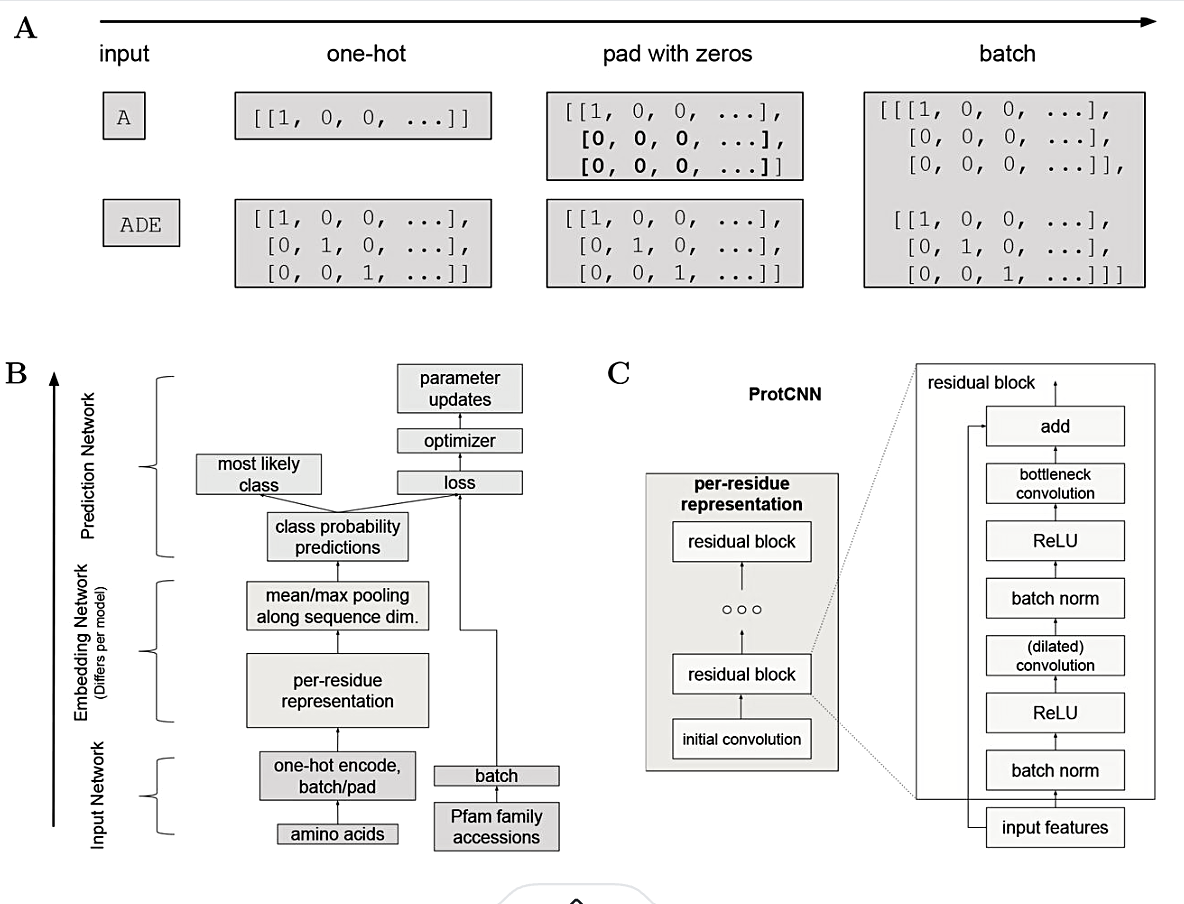

- One hot encoded unaligned sequence of amino acids is passed as the input to the network with zero padding.

- Residual blocks  [ResNet](https://arxiv.org/abs/1512.03385) includes dilated convolutions offering larger receptive field without increasing number of model parameters.
- Inspired By Reference Flow https://www.biorxiv.org/content/biorxiv/early/2019/07/15/626507/F6.large.jpg

Batch normalization, RELU actication & Conv1D filters

In [51]:
def residual_block(data, filters, d_rate):
  """
  _data: input
  _filters: convolution filters
  _d_rate: dilation rate
  """

  shortcut = data

  bn1 = BatchNormalization()(data)
  act1 = Activation('relu')(bn1)
  conv1 = Conv1D(filters, 1, dilation_rate=d_rate, padding='same', kernel_regularizer=l2(0.001))(act1)

  #bottleneck convolution
  bn2 = BatchNormalization()(conv1)
  act2 = Activation('relu')(bn2)
  conv2 = Conv1D(filters, 3, padding='same', kernel_regularizer=l2(0.001))(act2)

  #skip connection
  x = Add()([conv2, shortcut])

  return x

# *8.53 Softmax Classifier*

In [52]:
# model

x_input = Input(shape=(100, 21))

#initial conv
conv = Conv1D(128, 1, padding='same')(x_input) 

# per-residue representation
res1 = residual_block(conv, 128, 2)
res2 = residual_block(res1, 128, 3)

x = MaxPooling1D(3)(res2)
x = Dropout(0.5)(x)

# softmax classifier
x = Flatten()(x)
x_output = Dense(1000, activation='softmax', kernel_regularizer=l2(0.0001))(x)

model2 = Model(inputs=x_input, outputs=x_output)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model2.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 100, 21)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 100, 128)     2816        ['input_4[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 100, 128)    512         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 100, 128)     0           ['batch_normalization[0][0]

In [53]:
# Early Stopping
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

# 8.6 Evaluate our trained model on the test data
- Plotting Epoch vs Loss 

In [54]:
history2 = model2.fit(
    train_ohe, y_train,
    epochs=10, batch_size=256,
    validation_data=(val_ohe, y_val),
    callbacks=[es]
    )

Epoch 1/10
1717/1717 [==============================] - 61s 32ms/step - loss: 0.9036 - accuracy: 0.9305 - val_loss: 0.4642 - val_accuracy: 0.9828
Epoch 2/10
1717/1717 [==============================] - 52s 30ms/step - loss: 0.4392 - accuracy: 0.9788 - val_loss: 0.4464 - val_accuracy: 0.9851
Epoch 3/10
1717/1717 [==============================] - 52s 30ms/step - loss: 0.4279 - accuracy: 0.9816 - val_loss: 0.4350 - val_accuracy: 0.9856
Epoch 4/10
1717/1717 [==============================] - 52s 30ms/step - loss: 0.4158 - accuracy: 0.9825 - val_loss: 0.4323 - val_accuracy: 0.9875
Epoch 5/10
1717/1717 [==============================] - 52s 30ms/step - loss: 0.4145 - accuracy: 0.9828 - val_loss: 0.4254 - val_accuracy: 0.9866
Epoch 6/10
1717/1717 [==============================] - 52s 31ms/step - loss: 0.4000 - accuracy: 0.9838 - val_loss: 0.4195 - val_accuracy: 0.9871
Epoch 7/10
1717/1717 [==============================] - 52s 30ms/step - loss: 0.3988 - accuracy: 0.9838 - val_loss: 0.4159 -

In [55]:
# saving model weights.
model2.save_weights('drive/MyDrive/MLE/protein_data/model2.h5')

In [56]:
plot_history(history2)

KeyError: ignored

In [59]:
import gc; gc.collect()
display_model_score(
    model2,
    [train_ohe, y_train],
    [val_ohe, y_val],
    [test_ohe, y_test],
    256)

1717/1717 [==============================] - 18s 11ms/step - loss: 0.3562 - accuracy: 0.9964
Train loss:  0.35623741149902344
Train accuracy:  0.9964072108268738
----------------------------------------------------------------------
213/213 [==============================] - 2s 11ms/step - loss: 0.3982 - accuracy: 0.9874
Val loss:  0.3981635272502899
Val accuracy:  0.9874029755592346
----------------------------------------------------------------------
213/213 [==============================] - 2s 11ms/step - loss: 0.3997 - accuracy: 0.9876
Test loss:  0.39971640706062317
Test accuracy:  0.9875684976577759


# **9. SUMMARY OF FINDINGS**
A table of our model outputs

In [60]:
#table of models
x = PrettyTable()
x.field_names = ['Sr.no', 'Model', 'Train Acc', 'Val Acc','Test Acc']

x.add_row(['1.', 'Bidirectional LSTM', '0.930', '0.925', '0.925'])
x.add_row(['2.', 'ProtCNN', '0.996', '0.987', '0.988'])

print(x)

+-------+--------------------+-----------+---------+----------+
| Sr.no |       Model        | Train Acc | Val Acc | Test Acc |
+-------+--------------------+-----------+---------+----------+
|   1.  | Bidirectional LSTM |   0.930   |  0.925  |  0.925   |
|   2.  |      ProtCNN       |   0.996   |  0.987  |  0.988   |
+-------+--------------------+-----------+---------+----------+


# **10. DISCUSSION**
# 10.1 Results Summary
- We found that Bidirectional LSLTM...
- PRot CNN...
- x model works best (ours or another) makes sense because....

# 10.2 Answers to Proposed Research Questions
**1. Can we use deep learning that learns the relationship between unaligned amino acid sequences and their functional annotations across all families of the Pfam database?**

Combining deep models with existing methods significantly improves remote homology detection, creating the implication that deep models learn complementary information (Bileschi et al., 2022).  Currently, deep learning models for protein informatics is employed in 2 ways: i) direct annotation of the amino acid sequences (via supervised learning) - where annotation assigns labels to newly sequenced proteins, which is linked to a database; ii) creating protein representations (self-supervised sequence embedding).  

Research studies over the past 5 years have shown that deep learning is successful at predicting protein classifications and Pfam families Odrzywolek et al., 2022). 


**2. Can we improve class-wise accuracy versus existing published models?**

*Other projects on same dataset:*

Bileschi et al. 2019, concluded that deep models make fewer errors at annotating held-out test sequences than state of the art HMM and BLASTp approaches across both the random and clustered splits in analysis of the PFAM dataset.  Like us, they used a CNN model (ProtCNN) which significantly outperformed previous alignment-based methods for sequences with between 30 and 90% maximum identity with the training set (p < 0.05).  
They trained a ProtCNN model on Pfam-seed families with gene sequence fragments generated during a shotgun sequencing - functionally annotated, using homology-based tools  (BLAST13 or HMMER14) that search fragments of sequences against Pfam.  Bileschi et al., 2019 found that a single ProtCNN model displays similar performance to alignment-based methods across these remote sequences, while ProtENN obtains significantly greater accuracy across all bins in the Pfam set.  Bileschi et al suggest that it is important to stratify analyses by similarity of each test sequence to the closest sequence in the training set, to account for sequence similarity between the train and test data; and found that ProtENN is significantly more accurate for sequences with identity >32% to the training set.  The authors conducted a nearest-neighbor classification (Per-Family 1-NN) for each test sequence using cosine similarity in embedding space with the set of representatives and found that Per-Family 1-NN considerably improves accuracy vs. ProtCNN, almost the same as ProtENN; suggesting that the speed-accuracy tradeoff of ProtCNN vs. ProtENN could be avoided using improved machine learning methods (Bileschi et al., 2019). 
 
Another study, Dohan et al., 2021, switched from a CNN to a pre-trained transformer on the Pfam set, and improved model performance from 73.6% to 90.5% using a single model on a challenging clustering-based train-test split, where the ensemble of 59 CNNs achieved 89.0%. 

A study in 2021 called the trRosetta algorithm for protein structure prediction, used multiple sequence alignments from Pfam and applied a deep learning model to predict the transformations and structure parameters for each protein (Stroe, 2021).  They applied the Rosetta pipeline to predict the 3D structure with estimated global and local accuracy, and predicted inter-residue contacts/distances/orientations, as well as the top PDB templates (when detected) and the multiple sequence alignment.

*Studies on other datasets:*

The EnsembleFam model extracts the core characteristics of a protein family using similarity and dissimilarity features calculated from sequence homology relations. This model trained three separate Support Vector Machine (SVM) classifiers for each family using these features, and an ensemble prediction to classify proteins into the families, founded on the Clusters of Orthologous Groups (COG) dataset and G Protein-Coupled Receptor (GPCR) dataset. 

This EnsembleFam provided more accurate SVM-Pairwise, for every protein sequence, its pairwise similarity scores to every reference protein sequence are used to form its feature vector; making the feature vector bulky and time-consuming. In EnsembleFam, similarity scores are calculated by protein family - reducing the size of the feature vector; and it trains several SVMs for each family to make a prediction by ensembling individual predictions (Kabir et al. 2022).

**3. Can we outline bias and errors in our model, and suggest solutions to these?**
- bias towards the protein Hidden Markov Model (pHMM)?
> IE use Clusters of Orthologous Groups of proteins (COG) dataset- where protein family assignment in the COG database is done by pairwise sequence comparison in the whole-genome context;  and G Protein-Coupled Receptor (GPCR) datasets; which provides a hierarchical classification with family, subfamily and sub-subfamily label for GPCR proteins.
However, the labeled proteins are not only in shortage, limiting the potential of deep learning, but also skewed towards model organisms, which may result in biased models. (Odrzywolek et al., 2022)

To overcome these obstacles, more recent approaches use massive unlabeled datasets (UniParc, BFD, Pfam) to train self-supervised models. These models analyse raw amino acid sequences in an alignment-free fashion to learn statistical representations of a protein. The representation can then be effectively used for downstream analyses and predictions of, e.g. secondary or tertiary structure, protein stability, contact map39,40, protein function41,42, localization43,44, variant effect45, protein engineering45,46, remote homology detection39 and more. Moreover, deep-learning-based methods can be used to analyse proteins that do not resemble any catalogued proteins, which is particularly useful in the case of the under-annotated microbiome protein space. Deep-learning-based representations are computationally efficient and accurate, hence they seem appropriate to leverage large amounts of data in high-volume metagenomic studies. However, despite remarkable progress and breakthroughs in several tasks, deep-learning-based approaches are still not mature enough to become prevalent in protein informatics, especially in metagenomics, where further research is needed.

Here, we describe a deep learning approach, based on BiLSTM (Bidirectional Long Short-Term Memory) model47, which leverages deep sequence embeddings to understand their potential for solving metagenomic challenges. We trained the model on 20 million microbial proteins from the Unified Human Gastrointestinal Protein (UHGP) catalogue16, and then demonstrated the utility of the proposed representations on the Bacterial SwissProt database.



# **11.  CONCLUDING REMARKS**
Pfam has created many entries for domains of unknown function (DUF) and uncharacterized protein families (UPF); domains are being discovered with ongoing models, however, there remains many uncharacterized families and domains. Pfam-seed contains 1.34 million curated sequences, and the profile HMMs built from this data are used to annotate the >60 million Pfam sequences. The predictive accuracy of deep learning models typically improves as the amount of well-labelled training data increases; which is a suggestion for future studies - to use precisely labelled, more training data.  As the PFAM dataset and others like UniPROT continue to grow in an open source community, our comprehension of genomic functions grows in tandem.

Newer studies focus on function, 3D structure and inter-molecular interactions based on amino acid sequences, towards identifying previously unclassified proteins, understanding physiological and pathological interactions and building pharmaceutical models that can target specific protein abnormalities with high class and treatment accuracy.  The popular AlphaFold by DeepMind, predicts a protein’s 3D structure from its amino acid sequence using a database containing more than 200 million entries based on UniProt (sequences and annotations) (Varadi et al., 2022).  The visualization of protein structures is the largest benchmark in recent times in the way of proteinology. 

Another benchmark in understanding proteins is ProtMD's algorithm which calculates protein movements at an atomic level, where data is generated based on the protein molecule interactions; it is more generalized than AlphaFold, but maintains a similar performance level.  Released in December 2022, the model predicts a protein structure, sturctural change after interacting with drug molecules and thereby enables an understanding of the effect of drugs on the protein and body physiology (Tong, 2022).  Moreover, it can accurately predict drug-protein affinity without tedious and expensive clinical trials, making AI the clear victor in the way of new drug formulation, quickly.

# **12. QUESTIONS**
1. Effects of hyperparameter tuning?

# **13. REFERENCES**
- Alhamid, M (2021). LSTM and Bidirectional LSTM for Regression https://towardsdatascience.com/lstm-and-bidirectional-lstm-for-regression-4fddf910c655

- AlphaFold Protein Structure Database https://alphafold.ebi.ac.uk/

- Bileschi ML, Belanger D, Bryant DH, Sanderson T, Carter B, Sculley D, Bateman A, DePristo MA, Colwell LJ. Using deep learning to annotate the protein universe. Nat Biotechnol. 2022 Jun;40(6):932-937. doi: 10.1038/s41587-021-01179-w. Epub 2022 Feb 21. PMID: 35190689.

- Blum M, Chang H, Chuguransky S, Grego T, Kandasaamy S, Mitchell A, Nuka G, Paysan-Lafosse T, Qureshi M, Raj S, RichardsonL, Salazar GA, Williams L, Bork P, Bridge A, Gough J, Haft DH, Letunic I, Marchler-Bauer A, Mi H, Natale DA, Necci M, Orengo CA, Pandurangan AP, Rivoire C, Sigrist CJA, Sillitoe I, Thanki N, Thomas PD, Tosatto SCE, Wu CH, Bateman A and Finn RD. (2020). The InterPro protein families and domains database: 20 years on. Nucleic Acids Research, Nov 2020, (doi: 10.1093/nar/gkaa977). InterPRO Protein Classification https://www.ebi.ac.uk/interpro/ 

- Dohan D, Gane A, Bileschi ML, Belanger D, Colwell LJ (2021). Improving Protein Function Annotation via Unsupervised Pre-training: Robustness, Efficiency, and Insights. Proceedings of the 27th ACM SIGKDD Conference on Knowledge Discovery & Data Mining; 2021.

- DMNFarrell. (2018). Create an MHC-Class I binding predictor in Python https://dmnfarrell.github.io/bioinformatics/mhclearning

- Du et al, The trRosetta server for fast and accurate protein structure prediction, Nature Protocols, 16: 5634-5651 (2021).

- GeeksforGeeks (2022). ML Label Encoding of datasets in Python https://www.geeksforgeeks.org/ml-label-encoding-of-datasets-in-python/ 

- Hatch V. (2022). Deep learning models help predict protein function. https://www.embl.org/news/science/deep-learning-models-help-predict-protein-function/

- Jumper, J et al. Highly accurate protein structure prediction with AlphaFold. Nature (2021).

- Kabir, M.N., Wong, L. EnsembleFam: towards more accurate protein family prediction in the twilight zone. BMC Bioinformatics 23, 90 (2022). https://doi.org/10.1186/s12859-022-04626-w

- Odrzywolek K, Karwowska Z, Majta J, Byrski A, Milanowska-Zabel K, Kosciolek T. Deep embeddings to comprehend and visualize microbiome protein space. Sci Rep. 2022 Jun 20;12(1):10332. doi: 10.1038/s41598-022-14055-7. PMID: 35725732; PMCID: PMC9209496.

- Stroe, O (2021). Pfam releases structures for every protein family https://www.ebi.ac.uk/about/news/announcements/Pfam-protein-structures/

- Tong, Z. (2022). Chinese scientists make ‘impossible’ AI breakthrough in drug research. https://www.scmp.com/news/china/science/article/3203289/chinese-scientists-make-impossible-ai-breakthrough-drug-research

- Washington University, Biochemical Compounds Declarative Database at the Institute of Biomedical Computing. (2022). The Twenty Amino Acids http://www.cryst.bbk.ac.uk/education/AminoAcid/the_twenty.html

- Varadi, M et al. (2022). AlphaFold Protein Structure Database: massively expanding the structural coverage of protein-sequence space with high-accuracy models. Nucleic Acids Research.

# Thank you, from MLE 10 COHORT TEAM:

- **Anjana Sengupta**
- **Jonathan A. Grant**
- **Shaista Hussain**
- **Sam Deo**  
✌